In [1]:

import torch
from torchvision import models, transforms
import torch.nn as nn
import os
from PIL import Image
from torch.utils.data import Dataset






In [2]:
#!pip install torch torchvision

In [3]:
from torchvision import models
def get_model():
    """Load ResNet18 with a single output neuron for Binary Classification."""
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, 1)
    return model

In [4]:
def load_model_from_pth(checkpoint_path, device):
    """
    Loads the ResNet18 model from a standard PyTorch .pth state_dict.
    """
    model = get_model()
    # map_location ensures it loads on CPU if GPU is not available
    state_dict = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    print(f"✅ Model loaded from .pth: {checkpoint_path}")
    return model

def load_model_from_pkl(checkpoint_path, device):
    """
    Loads the ResNet18 model from a Flower .pkl checkpoint (list of NumPy arrays).
    """
    model = get_model()

    # Load the list of numpy arrays
    with open(checkpoint_path, "rb") as f:
        ndarrays = pickle.load(f)

    # Map the numpy arrays to the model's state_dict keys
    params_dict = zip(model.state_dict().keys(), ndarrays)
    state_dict = OrderedDict({k: torch.tensor(v, dtype=torch.float32) for k, v in params_dict})

    model.load_state_dict(state_dict, strict=True)
    model.to(device)
    model.eval()
    print(f"✅ Model loaded from .pkl: {checkpoint_path}")
    return model

In [5]:
from google.colab import drive
drive.mount('/content/drive')
PATH="/content/drive/MyDrive/AITDM/"
TEST_PATH="/content/val/"

Mounted at /content/drive


In [6]:
!unzip -o  /content/drive/MyDrive/AITDM/covid_val.zip -d /content

Streaming output truncated to the last 5000 lines.
  inflating: /content/val/86746808-b97b-4a47-b073-973fa4babd3f.jpg  
  inflating: /content/val/868aa791-fca9-4915-b8e2-c38460d90426.jpg  
  inflating: /content/val/8697ce4a-d16c-44f4-9271-393000aa9d42.jpg  
  inflating: /content/val/8698df10-24b5-4b01-ab93-373ba59e26ba.jpg  
  inflating: /content/val/869e160d-9d79-42dc-beab-04bd3607862a.jpg  
  inflating: /content/val/869facf4-a6d0-452b-b001-c7ca04524955.jpg  
  inflating: /content/val/86a95eba-c600-4016-8e14-febf0dff0653.jpg  
  inflating: /content/val/86ad951a-d0b6-4af7-b303-dd94c1dce684.jpg  
  inflating: /content/val/86b194b5-dc85-47a9-b77c-e17f68d6d5c9.jpg  
  inflating: /content/val/86b32de2-c74f-4446-9541-9a27e1021984.jpg  
  inflating: /content/val/86b4fe0b-3545-4b94-abcf-7710922257ce.jpg  
  inflating: /content/val/86bd39a4-568d-443c-9ad4-4c9807d7f136.jpg  
  inflating: /content/val/86c14816-f11b-4663-badd-50b8a6abded9.jpg  
  inflating: /content/val/86c27916-8e16-46f3-bfc3-41

In [7]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model=load_model_from_pth(PATH + "resnet_fedavg/global_model_final.pth", device)
model.to(device).eval()

cpu
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 86.3MB/s]


✅ Model loaded from .pth: /content/drive/MyDrive/AITDM/resnet_fedavg/global_model_final.pth


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [8]:
class CovidDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['filename']
        img_path = os.path.join(self.img_dir, img_name)

        if os.path.exists(img_path):
            image = Image.open(img_path).convert('RGB')
        else:
            # This is a safety net; if this triggers, the model won't learn.
            image = Image.new('RGB', (256, 256))
            print("Failure!!!")

        if self.transform:
            image = self.transform(image)

        # Ensure label is read correctly from "positive"/"negative"
        label_str = str(self.df.iloc[idx]['label']).lower()
        label = torch.tensor([1.0 if label_str == "positive" else 0.0], dtype=torch.float32)
        return image, label, img_name, img_path

File: CR.1.2.840.113564.1722810170.20200318082923328940.1003000225002.jpg | Label: tensor([1.]) | Prob: 1.0000


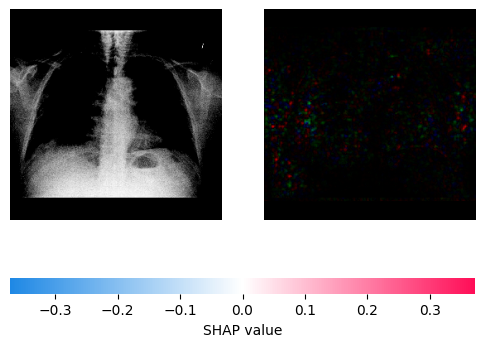

File: CR.1.2.840.113564.1722810170.20200320011259312440.1003000225002.jpg | Label: tensor([1.]) | Prob: 1.0000


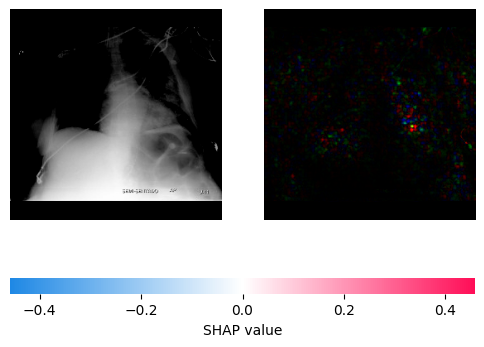

File: sub-S03044_ses-E06138_run-1_bp-chest_vp-ap_cr-corrected.jpg | Label: tensor([1.]) | Prob: 0.9999


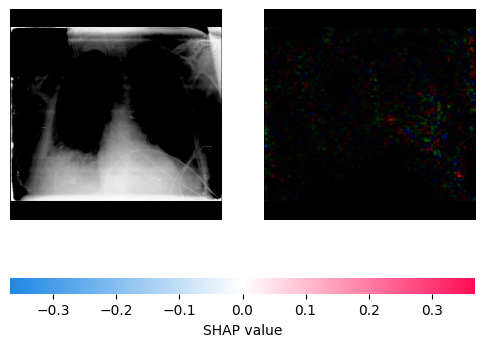

File: sub-S03044_ses-E07712_run-1_bp-chest_vp-ap_cr-corrected.jpg | Label: tensor([1.]) | Prob: 1.0000


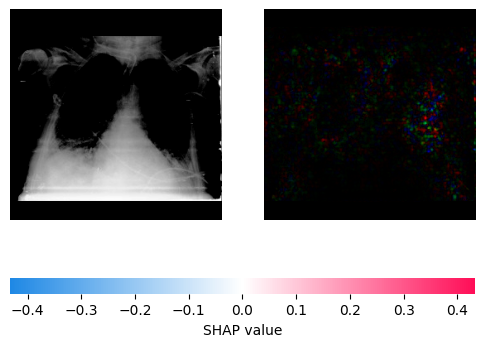

File: sub-S03044_ses-E06790_run-1_bp-chest_vp-pa_dx-corrected.jpg | Label: tensor([1.]) | Prob: 1.0000


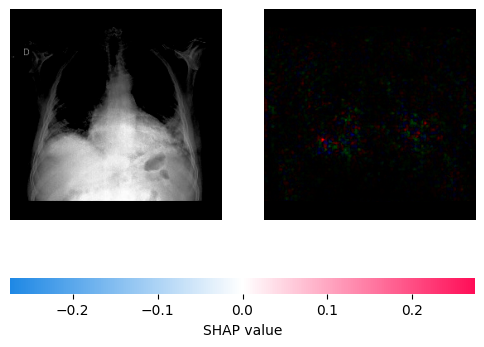

In [9]:
import pandas as pd
import numpy as np
import torch
import shap
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms


test_df  = pd.read_csv(PATH  + "val.txt",  sep=" ", header=None, index_col=False, names=["patient_id", "filename", "label", "source"])

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

dataset = CovidDataset(test_df, img_dir=TEST_PATH, transform=transform)

# --- SHAP INITIALIZATION ---

# 1. Prepare Background Data
# SHAP needs a baseline to compare against. We take a small batch from your dataset.
background_images = []
for i in range(10):  # Using 10 images as the background reference
    img, _, _, _ = dataset[i]
    background_images.append(img)
background_tensor = torch.stack(background_images).to(device)

# 2. Initialize the Explainer
# We pass the model and the background images
explainer = shap.GradientExplainer(model, background_tensor)

# --- INFERENCE & EXPLANATION LOOP ---

for i in range(len(dataset)):
    if i == 5:
        break

    image, label, image_name, img_path = dataset[i]
    input_batch = image.unsqueeze(0).to(device) # Shape: (1, 3, 256, 256)

    # Get model prediction
    output = model(input_batch)
    prob = torch.sigmoid(output).item()

    # 3. Calculate SHAP values
    # This returns a list of arrays (one for each output class)
    # shap_values[0] will represent the importance for the prediction
    shap_values = explainer.shap_values(input_batch)

    # 4. Prepare for Visualization
    # SHAP expects (batch, height, width, channels) for plotting
    # We transpose from (1, 3, 256, 256) -> (1, 256, 256, 3)
    input_numpy = input_batch.cpu().permute(0, 2, 3, 1).numpy()

    # SHAP values need the same transpose
    # shap_values is usually a list; if binary classification, it might be a single array
    if isinstance(shap_values, list):
        shap_numpy = [np.swapaxes(np.swapaxes(s, 1, 2), 2, 3) for s in shap_values]
    else:
        shap_numpy = np.swapaxes(np.swapaxes(shap_values, 1, 2), 2, 3)

    # 5. Plotting
    print(f"File: {image_name} | Label: {label} | Prob: {prob:.4f}")

    # shap.image_plot(shap_values, pixel_values)
    # Red pixels = increased probability, Blue pixels = decreased probability
    shap.image_plot(shap_numpy, input_numpy)